## COVID-19 Exploratory Data Analysis

In [35]:
# importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# loading the dataset
df = pd.read_csv("covid19_latest.csv")

#### BASIC DATA UNDERSTANDING

In [36]:
# displaying the first 5 rows of the dataset
print("\nFirst 5 Rows:")
print(df.head())


First 5 Rows:
  Country/Region  Confirmed  Deaths  Recovered  Active  New cases  New deaths  \
0    Afghanistan      36263    1269      25198    9796        106          10   
1        Albania       4880     144       2745    1991        117           6   
2        Algeria      27973    1163      18837    7973        616           8   
3        Andorra        907      52        803      52         10           0   
4         Angola        950      41        242     667         18           1   

   New recovered  Deaths / 100 Cases  Recovered / 100 Cases  \
0             18                3.50                  69.49   
1             63                2.95                  56.25   
2            749                4.16                  67.34   
3              0                5.73                  88.53   
4              0                4.32                  25.47   

   Deaths / 100 Recovered  Confirmed last week  1 week change  \
0                    5.04                35526        

In [37]:
# displaying the last 5 rows of the dataset
print("\nLast 5 Rows:")
print(df.tail())


Last 5 Rows:
         Country/Region  Confirmed  Deaths  Recovered  Active  New cases  \
182  West Bank and Gaza      10621      78       3752    6791        152   
183      Western Sahara         10       1          8       1          0   
184               Yemen       1691     483        833     375         10   
185              Zambia       4552     140       2815    1597         71   
186            Zimbabwe       2704      36        542    2126        192   

     New deaths  New recovered  Deaths / 100 Cases  Recovered / 100 Cases  \
182           2              0                0.73                  35.33   
183           0              0               10.00                  80.00   
184           4             36               28.56                  49.26   
185           1            465                3.08                  61.84   
186           2             24                1.33                  20.04   

     Deaths / 100 Recovered  Confirmed last week  1 week change  \

In [38]:
# checking the shape of the dataset
print("\nShape of Dataset:")
print(df.shape)


Shape of Dataset:
(187, 15)


In [40]:
# checking for column names in the dataset
print("\nColumns in Dataset:")
print(df.columns)


Columns in Dataset:
Index(['Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active',
       'New cases', 'New deaths', 'New recovered', 'Deaths / 100 Cases',
       'Recovered / 100 Cases', 'Deaths / 100 Recovered',
       'Confirmed last week', '1 week change', '1 week % increase',
       'WHO Region'],
      dtype='object')


In [41]:
# checking for data types of each column
df.dtypes

Country/Region             object
Confirmed                   int64
Deaths                      int64
Recovered                   int64
Active                      int64
New cases                   int64
New deaths                  int64
New recovered               int64
Deaths / 100 Cases        float64
Recovered / 100 Cases     float64
Deaths / 100 Recovered    float64
Confirmed last week         int64
1 week change               int64
1 week % increase         float64
WHO Region                 object
dtype: object

In [42]:
# checking for summary of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country/Region          187 non-null    object 
 1   Confirmed               187 non-null    int64  
 2   Deaths                  187 non-null    int64  
 3   Recovered               187 non-null    int64  
 4   Active                  187 non-null    int64  
 5   New cases               187 non-null    int64  
 6   New deaths              187 non-null    int64  
 7   New recovered           187 non-null    int64  
 8   Deaths / 100 Cases      187 non-null    float64
 9   Recovered / 100 Cases   187 non-null    float64
 10  Deaths / 100 Recovered  187 non-null    float64
 11  Confirmed last week     187 non-null    int64  
 12  1 week change           187 non-null    int64  
 13  1 week % increase       187 non-null    float64
 14  WHO Region              187 non-null    ob

#### DATA CLEANING

In [43]:
# checking for missing values in the dataset
df.isnull().sum()

Country/Region            0
Confirmed                 0
Deaths                    0
Recovered                 0
Active                    0
New cases                 0
New deaths                0
New recovered             0
Deaths / 100 Cases        0
Recovered / 100 Cases     0
Deaths / 100 Recovered    0
Confirmed last week       0
1 week change             0
1 week % increase         0
WHO Region                0
dtype: int64

In [44]:
# handling missing values 
df.fillna(0, inplace=True)

In [45]:
# checking for duplicate rows in the dataset
df.duplicated().sum()

np.int64(0)

In [46]:
# removing duplicate rows from the dataset
df.drop_duplicates(inplace=True)

#### OUTLIER DETECTION

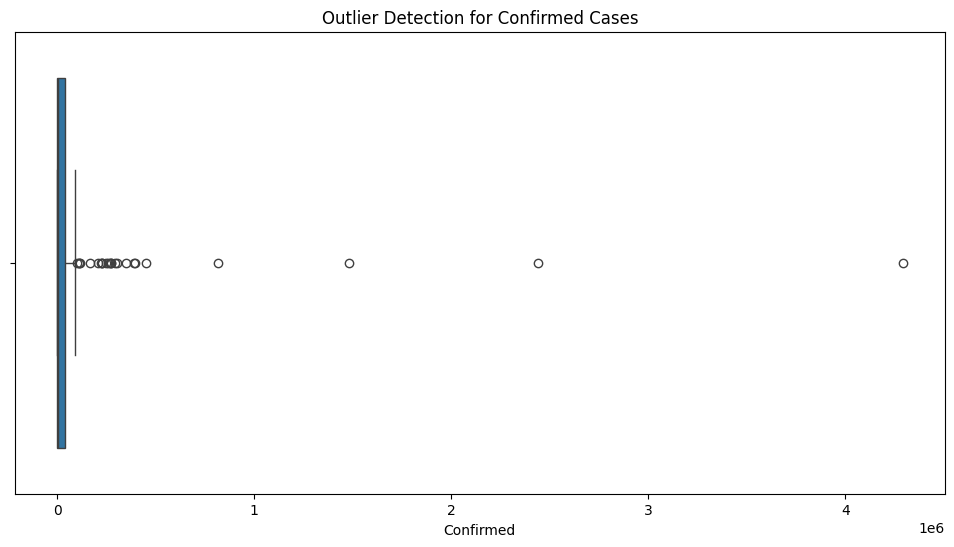

In [47]:
# visualizing the distribution of confirmed cases using a boxplot to detect outliers
plt.figure(figsize=(12,6))
sns.boxplot(x=df['Confirmed'])
plt.title("Outlier Detection for Confirmed Cases")
plt.show()

In [48]:
# calculating the interquartile range (IQR) to identify outliers in the 'Confirmed' columns

Q1 = df['Confirmed'].quantile(0.25)
Q3 = df['Confirmed'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[
    (df['Confirmed'] < lower_bound) |
    (df['Confirmed'] > upper_bound)
]

print(outliers.shape)

(24, 15)


#### FEATURE ENGINEERING

In [49]:
# creating a new column 'Active Cases' to represent the number of active cases
df['Active Cases'] = df['Confirmed'] - df['Deaths'] - df['Recovered']

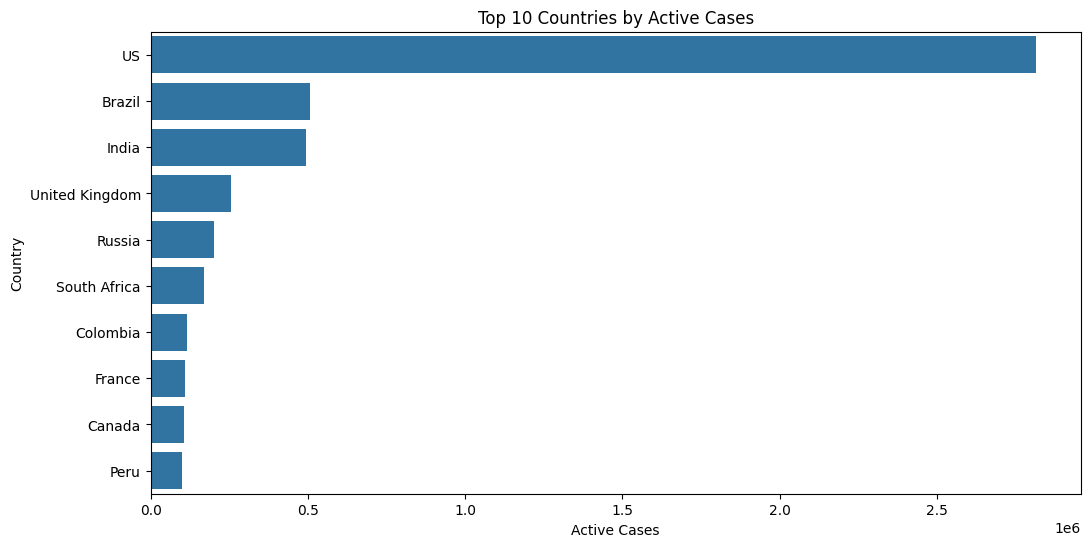

In [50]:
# Grouping active cases country-wise

active_cases = df.groupby('Country/Region')['Active Cases'].sum()
top_active = active_cases.sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(
    x=top_active.values,
    y=top_active.index
)
plt.title("Top 10 Countries by Active Cases")
plt.xlabel("Active Cases")
plt.ylabel("Country")
plt.show()

#### STATISTICAL ANALYSIS

In [51]:
# checking for summary statistics of the dataset
df.describe()

,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,Active Cases
count,1.870000e+02,187.000000,1.870000e+02,1.870000e+02,187.000000,187.000000,187.000000,187.000000,187.000000,187.00,1.870000e+02,187.000000,187.000000,1.870000e+02
mean,8.813094e+04,3497.518717,5.063148e+04,3.400194e+04,1222.957219,28.957219,933.812834,3.019519,64.820535,inf,7.868248e+04,9448.459893,13.606203,3.400194e+04
std,3.833187e+05,14100.002482,1.901882e+05,2.133262e+05,5710.374790,120.037173,4197.719635,3.454302,26.287694,NaN,3.382737e+05,47491.127684,24.509838,2.133262e+05
min,1.000000e+01,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.00,1.000000e+01,-47.000000,-3.840000,0.000000e+00
25%,1.114000e+03,18.500000,6.265000e+02,1.415000e+02,4.000000,0.000000,0.000000,0.945000,48.770000,1.45,1.051500e+03,49.000000,2.775000,1.415000e+02
50%,5.059000e+03,108.000000,2.815000e+03,1.600000e+03,49.000000,1.000000,22.000000,2.150000,71.320000,3.62,5.020000e+03,432.000000,6.890000,1.600000e+03
75%,4.046050e+04,734.000000,2.260600e+04,9.149000e+03,419.500000,6.000000,221.000000,3.875000,86.885000,6.44,3.708050e+04,3172.000000,16.855000,9.149000e+03
max,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06,56336.000000,1076.000000,33728.000000,28.560000,100.000000,inf,3.834677e+06,455582.000000,226.320000,2.816444e+06


In [52]:
# checking for correlation between numerical columns in the dataset
df.corr(numeric_only=True)

,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,Active Cases
Confirmed,1.000000,0.934698,0.906377,0.927018,0.909720,0.871683,0.859252,0.063550,-0.064815,0.025175,0.999127,0.954710,-0.010161,0.927018
Deaths,0.934698,1.000000,0.832098,0.871586,0.806975,0.814161,0.765114,0.251565,-0.114529,0.169006,0.939082,0.855330,-0.034708,0.871586
Recovered,0.906377,0.832098,1.000000,0.682103,0.818942,0.820338,0.919203,0.048438,0.026610,-0.027277,0.899312,0.910013,-0.013697,0.682103
Active,0.927018,0.871586,0.682103,1.000000,0.851190,0.781123,0.673887,0.054380,-0.132618,0.058386,0.931459,0.847642,-0.003752,1.000000
New cases,0.909720,0.806975,0.818942,0.851190,1.000000,0.935947,0.914765,0.020104,-0.078666,-0.011637,0.896084,0.959993,0.030791,0.851190
New deaths,0.871683,0.814161,0.820338,0.781123,0.935947,1.000000,0.889234,0.060399,-0.062792,-0.020750,0.862118,0.894915,0.025293,0.781123
New recovered,0.859252,0.765114,0.919203,0.673887,0.914765,0.889234,1.000000,0.017090,-0.024293,-0.023340,0.839692,0.954321,0.032662,0.673887
Deaths / 100 Cases,0.063550,0.251565,0.048438,0.054380,0.020104,0.060399,0.017090,1.000000,-0.168920,0.334594,0.069894,0.015095,-0.134534,0.054380
Recovered / 100 Cases,-0.064815,-0.114529,0.026610,-0.132618,-0.078666,-0.062792,-0.024293,-0.168920,1.000000,-0.295381,-0.064600,-0.063013,-0.394254,-0.132618
Deaths / 100 Recovered,0.025175,0.169006,-0.027277,0.058386,-0.011637,-0.020750,-0.023340,0.334594,-0.295381,1.000000,0.030460,-0.013763,-0.049083,0.058386


In [53]:
# performing skewness analysis to understand the distribution of confirmed cases, deaths, recoveries and active cases
print("\nSkewness Analysis:")
print(df[['Confirmed','Deaths','Recovered','Active']].skew())


Skewness Analysis:
Confirmed     8.725676
Deaths        7.464481
Recovered     6.983644
Active       12.182067
dtype: float64


#### UNIVARIATE ANALYSIS

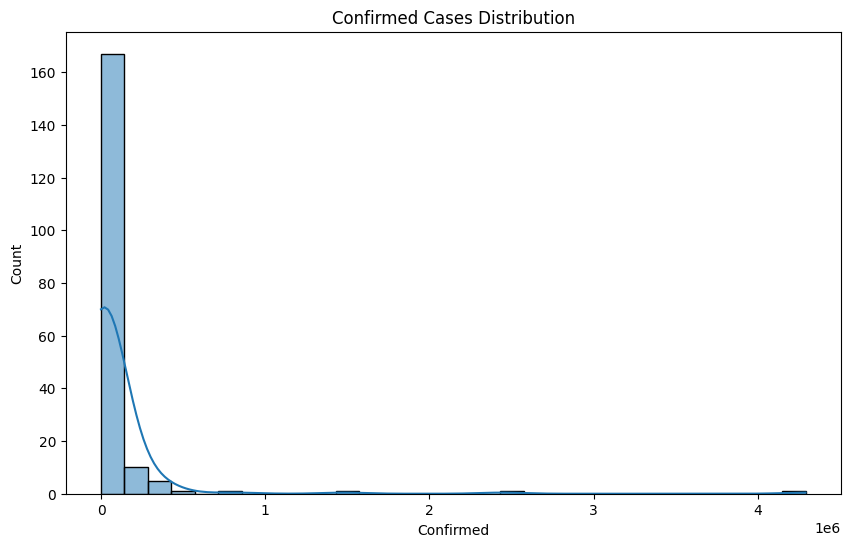

In [54]:
# visualizing the distribution of confirmed cases using a histogram

plt.figure(figsize=(10,6))
sns.histplot(df['Confirmed'], bins=30, kde=True)
plt.title("Confirmed Cases Distribution")
plt.show()

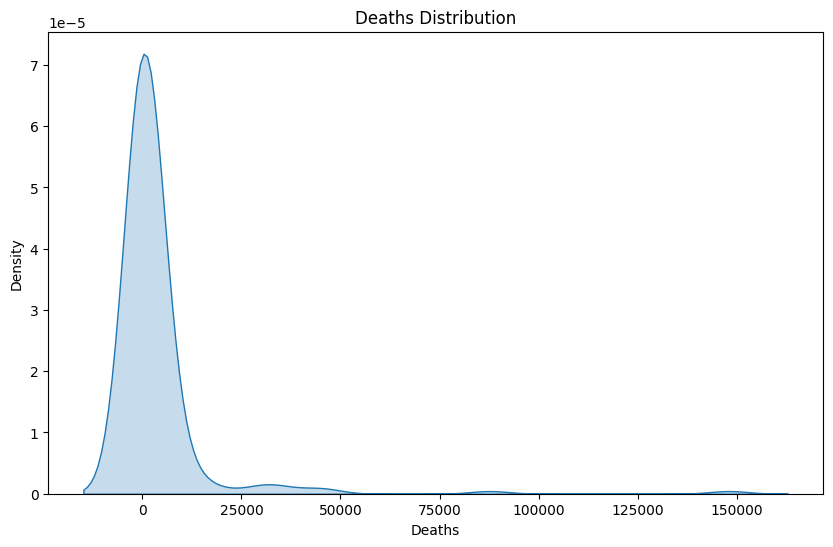

In [55]:
# visualizing the distribution of deaths using a kernel density estimate (KDE) plot

plt.figure(figsize=(10,6))
sns.kdeplot(df['Deaths'], fill=True)
plt.title("Deaths Distribution")
plt.show()

#### BIVARIATE ANALYSIS


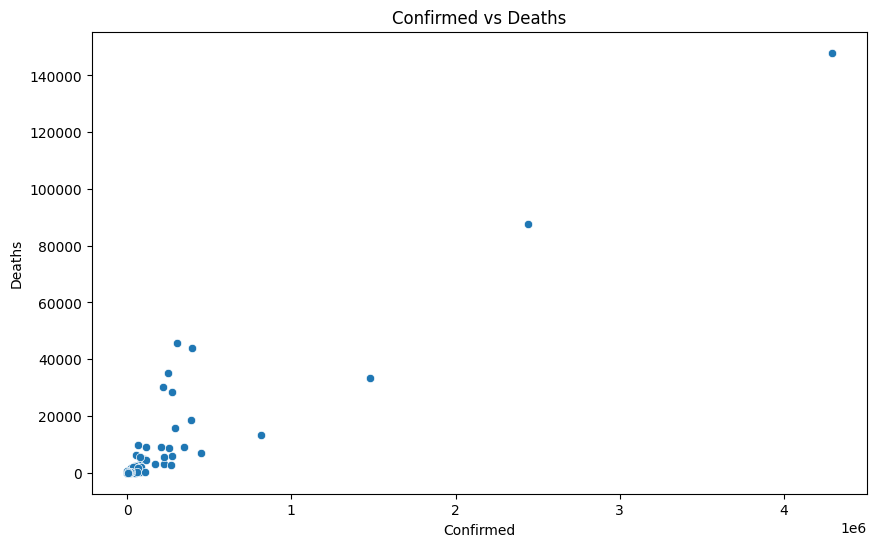

In [56]:
# visualizing the relationship between confirmed cases and deaths using a scatter plot

plt.figure(figsize=(10,6))
sns.scatterplot(
    x=df['Confirmed'],
    y=df['Deaths']
)
plt.title("Confirmed vs Deaths")
plt.show()

#### MULTIVARIATE ANALYSIS

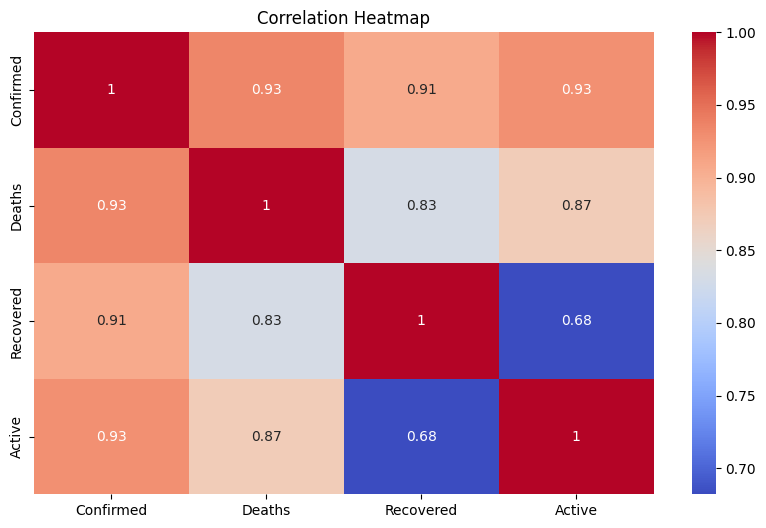

In [57]:
# visualizing the correlation between numerical columns using a heatmap

plt.figure(figsize=(10,6))
sns.heatmap(
    df[['Confirmed','Deaths','Recovered','Active']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

#### VISUALIZATION & INSIGHT EXTRACTION

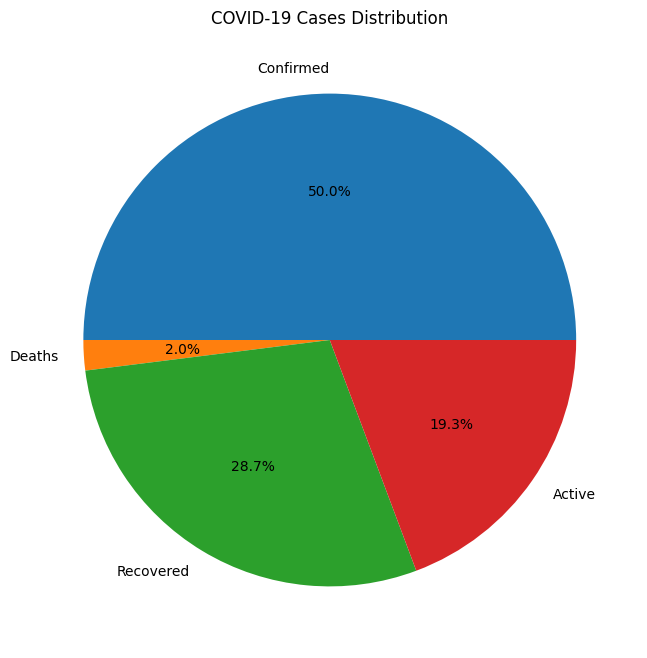

In [58]:
# visualizing the distribution of confirmed cases, deaths, recoveries and active cases using a pie chart

labels = ['Confirmed', 'Deaths', 'Recovered', 'Active']
values = [
    df['Confirmed'].sum(),
    df['Deaths'].sum(),
    df['Recovered'].sum(),
    df['Active'].sum()
]
plt.figure(figsize=(8,8))
plt.pie(
    values,
    labels=labels,
    autopct='%1.1f%%'
)
plt.title("COVID-19 Cases Distribution")
plt.show()

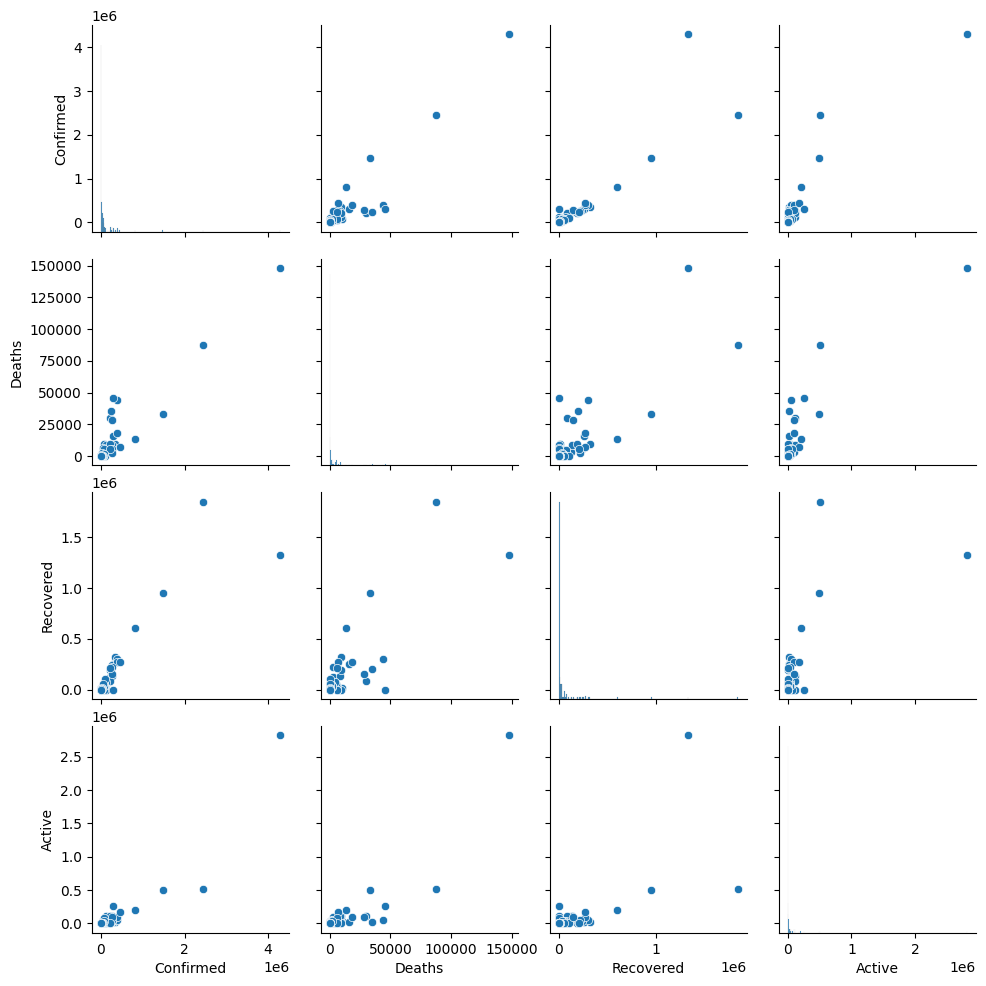

In [59]:
# visualizing the pairwise relationships between confirmed cases, deaths, recoveries, and active cases using a pairplot
sns.pairplot(
    df[['Confirmed','Deaths','Recovered','Active']] )
plt.show()

Index(['Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active',
       'New cases', 'New deaths', 'New recovered', 'Deaths / 100 Cases',
       'Recovered / 100 Cases', 'Deaths / 100 Recovered',
       'Confirmed last week', '1 week change', '1 week % increase',
       'WHO Region', 'Active Cases'],
      dtype='object')


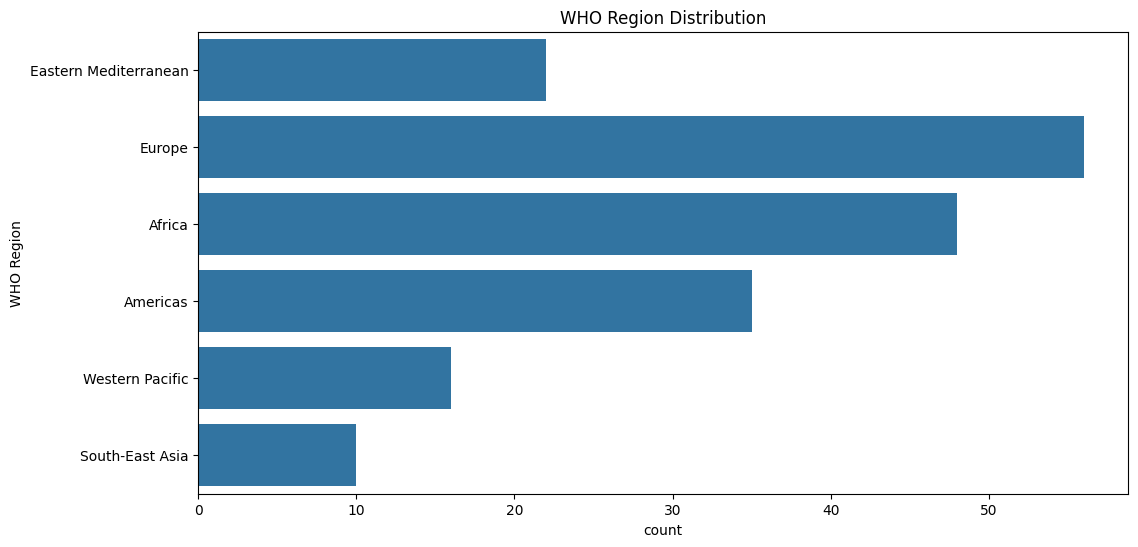

In [60]:
# visualizing the distribution of WHO regions in the dataset using a count plot

print(df.columns)
plt.figure(figsize=(12,6))
sns.countplot(
    y=df['WHO Region']
)
plt.title("WHO Region Distribution")
plt.show()

#### CONCLUSION


##### The Exploratory Data Analysis (EDA) of the COVID-19 dataset provided valuable insights into the global impact of the pandemic. Through data cleaning, handling missing values, duplicate removal, statistical analysis, and visualization, important patterns and relationships were identified within the dataset.

##### The analysis showed that some countries experienced significantly higher confirmed, death, and recovery cases compared to others. Correlation analysis revealed a strong positive relationship between confirmed cases and death cases, indicating that regions with higher infection rates also recorded higher fatalities. Outlier detection highlighted extreme case values in heavily affected countries, while distribution plots demonstrated the uneven spread of COVID-19 across different regions.

##### Feature engineering techniques such as calculating active cases, death rate, and recovery rate helped in understanding the severity and recovery trends of the pandemic more effectively. Various visualizations including bar charts, histograms, scatter plots, heatmaps, boxplots, and pie charts made the dataset easier to interpret and analyze.